# Bays (2014) Figure 3 — Cued vs Uncued + Optimal Weighting (GP Mixed-Selectivity)

Uses our **mixed-selectivity GP model** with population-level DN.
All N neurons encode all locations simultaneously.

**Attentional gain α** scales the cued location's **log-drive** for each neuron:

$$\log r_n^{\text{pre}} = \alpha \cdot f_{n,\text{cued}}(\theta_{\text{cued}}) + \sum_{k \neq \text{cued}} f_{n,k}(\theta_k)$$

This differs from the old implementation (log(α) additive constant) which cancelled
in DN. Here, α amplifies the **tuning curve values** at the cued location, creating
neuron-specific effects (neurons well-tuned to the cued item get disproportionately
boosted) that survive divisive normalization.

**DN** is our standard population-level formula over the same N neurons:
$$r_n^{\text{post}} = \gamma \cdot \frac{r_n^{\text{pre}}}{\sigma^2 + N^{-1}\sum_j r_j^{\text{pre}}}$$

**Panels:** a (error distributions), b (variance), c (kurtosis), d (optimal α)

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = str(Path.cwd().parents[1])
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
from scipy.special import logsumexp, i0, i1
from scipy.optimize import brentq

from core.encoder.gaussian_process import generate_neuron_population
from core.decoder.ml_decoder import decode, circular_error

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1


## Von Mises KDE + Circular statistics

In [2]:
def vonmises_kde(data, eval_points, kappa):
    """Circular KDE using von Mises kernels (no boundary artifacts at ±π)."""
    data = np.asarray(data)
    eval_points = np.asarray(eval_points)
    n = len(data)
    diff = eval_points[:, None] - data[None, :]
    log_norm = np.log(2.0 * np.pi * float(i0(kappa)))
    log_kernels = kappa * np.cos(diff) - log_norm
    return np.exp(logsumexp(log_kernels, axis=1) - np.log(n))


KAPPA_KDE = 25.0


def circular_variance_bays(errors):
    """σ² = −2 log |m̄₁| (Fisher 1995 / Bays 2014)."""
    R = np.abs(np.mean(np.exp(1j * errors)))
    return -2.0 * np.log(max(R, 1e-15))


def circular_kurtosis_bays(errors):
    """Fisher (1995): k = [ρ₂cos(…) − ρ₁⁴] / (1−ρ₁)²."""
    m1 = np.mean(np.exp(1j * errors))
    m2 = np.mean(np.exp(2j * errors))
    rho1 = np.abs(m1)
    rho2 = np.abs(m2)
    V = 1.0 - rho1
    if V < 1e-10:
        return 0.0
    phase_correction = np.cos(np.angle(m2) - 2 * np.angle(m1))
    return (rho2 * phase_correction - rho1**4) / (V**2)

## Population generation

In [3]:
def generate_population(M, n_theta, lengthscale, n_locations=1, seed=42):
    """Generate GP population with homogeneous amplitude (gain_variability=0)."""
    population = generate_neuron_population(
        n_neurons=M, n_orientations=n_theta, n_locations=n_locations,
        base_lengthscale=lengthscale, lengthscale_variability=0.0,
        seed=seed, gain_variability=0.0)
    thetas = population[0]['orientations']
    f_all = []
    for loc in range(n_locations):
        f_loc = np.array([population[n]['f_samples'][loc, :] for n in range(M)])
        f_all.append(f_loc)
    return thetas, f_all

## Configuration

In [4]:
M = 100            # neurons (same population encodes all locations)
N_THETA = 128      # orientation grid resolution
N_TRIALS = 5000    # trials for final statistics
N_TRIALS_SWEEP = 2000  # trials per alpha in optimisation sweep
T_D = 0.1          # decoding window (s)
SIGMA_SQ = 1e-6    # semi-saturation constant

# Bays (2014) fitted parameters
OMEGA_BAYS = 0.52
GAMMA_BAYS = 119.0

# CORRECTED: ω = λ², so λ = √ω
LAMBDA_BASE = np.sqrt(OMEGA_BAYS)   # = 0.721
GAMMA = GAMMA_BAYS / M              # = 1.19 Hz per neuron

SET_SIZES = [2, 4, 8]     # no N=1 — cueing is meaningless with one item
CUE_RATIO = 3.0           # cued item probed 3x more often

ALPHA_RANGE = (0.5, 5.0)
N_ALPHA = 30

SEED = 42

print(f'Config: M={M}, N_THETA={N_THETA}')
print(f'lambda={LAMBDA_BASE:.4f} (omega = lambda^2 = {LAMBDA_BASE**2:.3f})')
print(f'gamma={GAMMA:.3f} Hz/neuron, gamma_total={GAMMA*M:.1f} Hz')
print(f'Alpha sweep: {N_ALPHA} log-spaced values in [{ALPHA_RANGE[0]}, {ALPHA_RANGE[1]}]')

Config: M=100, N_THETA=128
lambda=0.7211 (omega = lambda^2 = 0.520)
gamma=1.190 Hz/neuron, gamma_total=119.0 Hz
Alpha sweep: 30 log-spaced values in [0.5, 5.0]


## Generate GP tuning curves

In [5]:
max_locs = max(SET_SIZES)
thetas, f_all = generate_population(M, N_THETA, LAMBDA_BASE, max_locs, SEED)

print(f'Generated population: {M} neurons, {max_locs} locations')
print(f'f_all[0].shape = {f_all[0].shape}  (M × N_THETA)')

Generated population: 100 neurons, 8 locations
f_all[0].shape = (100, 128)  (M × N_THETA)


## Weighted trial engine (mixed-selectivity with α scaling)

**Encoding with attentional gain:**

$$\log r_n^{\text{pre}} = \alpha \cdot f_{n,\text{cued}}(\theta_{\text{cued}}) + \sum_{k \neq \text{cued}} f_{n,k}(\theta_k)$$

α **scales** the cued location's tuning curve values in the exponent.
Unlike log(α) (a constant), α·f_{n,k} varies by neuron, so it does NOT cancel in DN.
Neurons well-tuned to the cued item get a disproportionate boost.

**DN:** standard population-level over the same M neurons.

**Decoding:** factorised ML using **unweighted** tuning curves (decoder doesn't know α).

In [6]:
def run_weighted_trials(f_all, thetas, N_items, cued_loc, probed_loc,
                        alpha_cued, gamma, T_d, sigma_sq,
                        n_trials, rng):
    """
    Mixed-selectivity trial engine with attentional gain α.

    Encoding:
      log_r_pre_n = α · f_{n,cued}(θ_cued) + Σ_{k≠cued} f_{n,k}(θ_k)
      r_pre = exp(log_r_pre)
      DN: r_post = γ · r_pre / (σ² + mean(r_pre))

    Decoding:
      Factorised ML using unweighted tuning curves.

    Parameters
    ----------
    f_all : list of (M, N_THETA) arrays — GP log-tuning per location
    thetas : (N_THETA,) — orientation grid
    N_items : int — number of items (locations used)
    cued_loc : int — which location is cued (gets α scaling)
    probed_loc : int — which location is probed for recall
    alpha_cued : float — scaling factor for cued location's log-drive
    gamma : float — per-neuron mean rate (Hz)
    T_d, sigma_sq : float
    n_trials : int
    rng : np.random.RandomState

    Returns
    -------
    errors : (n_trials,) — circular decoding errors
    """
    M_neurons, n_theta = f_all[0].shape
    f_active = [f_all[loc] for loc in range(N_items)]
    errors = np.empty(n_trials)

    for t in range(n_trials):
        theta_idx = rng.randint(n_theta, size=N_items)

        # ENCODING: α scales cued location's log-drive
        log_r_pre = np.zeros(M_neurons)
        for k in range(N_items):
            f_nk = f_active[k][:, theta_idx[k]]  # (M,) — each neuron's tuning
            if k == cued_loc:
                log_r_pre += alpha_cued * f_nk    # α SCALES the tuning values
            else:
                log_r_pre += f_nk

        # DN: standard population-level over M neurons
        log_r_pre -= np.max(log_r_pre)  # numerical stability (cancels in ratio)
        r_pre = np.exp(log_r_pre)
        D = sigma_sq + np.mean(r_pre)
        rates = gamma * r_pre / D

        # Poisson spikes
        counts = rng.poisson(rates * T_d)

        # DECODING: factorised ML with UNWEIGHTED tuning curves
        theta_hat, _ = decode(counts, f_active, thetas, probed_loc)
        theta_true = thetas[theta_idx[probed_loc]]
        errors[t] = circular_error(theta_true, theta_hat)

    return errors

## Find optimal α + run full trials

In [7]:
t0 = time.time()

alpha_values = np.logspace(np.log10(ALPHA_RANGE[0]), np.log10(ALPHA_RANGE[1]), N_ALPHA)

# Phase 1: find optimal alpha per set size
# cost(α) = p_cued · σ²_cued(α) + (1 − p_cued) · σ²_uncued(α)
optimal_alphas = {}
for N in SET_SIZES:
    p_c = CUE_RATIO / (CUE_RATIO + N - 1)
    best_cost, best_alpha = np.inf, 1.0
    print(f'  N={N} (p_cued={p_c:.2f}): sweeping {N_ALPHA} alpha values...')
    for alpha in alpha_values:
        # Cued trials: probe the cued item (location 0)
        rng_c = np.random.RandomState(SEED + N + int(alpha * 1000))
        ec = run_weighted_trials(
            f_all, thetas, N, cued_loc=0, probed_loc=0,
            alpha_cued=alpha, gamma=GAMMA,
            T_d=T_D, sigma_sq=SIGMA_SQ, n_trials=N_TRIALS_SWEEP, rng=rng_c)

        # Uncued trials: probe an uncued item (location 1)
        rng_u = np.random.RandomState(SEED + N + int(alpha * 1000) + 500000)
        eu = run_weighted_trials(
            f_all, thetas, N, cued_loc=0, probed_loc=1,
            alpha_cued=alpha, gamma=GAMMA,
            T_d=T_D, sigma_sq=SIGMA_SQ, n_trials=N_TRIALS_SWEEP, rng=rng_u)

        cost = p_c * circular_variance_bays(ec) + (1 - p_c) * circular_variance_bays(eu)
        if cost < best_cost:
            best_cost, best_alpha = cost, alpha
    optimal_alphas[N] = best_alpha
    print(f'    -> α*={best_alpha:.3f}')

print(f'\nPhase 1 done in {time.time()-t0:.1f}s')

# Phase 2: full trials at optimal alpha
summary = {}
for N in SET_SIZES:
    alpha_opt = optimal_alphas[N]

    rng_c = np.random.RandomState(SEED + N * 10000)
    ec = run_weighted_trials(
        f_all, thetas, N, cued_loc=0, probed_loc=0,
        alpha_cued=alpha_opt, gamma=GAMMA,
        T_d=T_D, sigma_sq=SIGMA_SQ, n_trials=N_TRIALS, rng=rng_c)

    rng_u = np.random.RandomState(SEED + N * 10000 + 500000)
    eu = run_weighted_trials(
        f_all, thetas, N, cued_loc=0, probed_loc=1,
        alpha_cued=alpha_opt, gamma=GAMMA,
        T_d=T_D, sigma_sq=SIGMA_SQ, n_trials=N_TRIALS, rng=rng_u)

    # Combined errors (cued + uncued in proportion to test frequency)
    p_c = CUE_RATIO / (CUE_RATIO + N - 1)
    nc = int(round(p_c * N_TRIALS))
    ea = np.concatenate([ec[:nc], eu[:N_TRIALS - nc]])

    summary[N] = {
        'alpha': alpha_opt,
        'err_cued': ec, 'err_uncued': eu, 'err_all': ea,
        'vc': circular_variance_bays(ec),
        'vu': circular_variance_bays(eu),
        'va': circular_variance_bays(ea),
        'kc': circular_kurtosis_bays(ec),
        'ku': circular_kurtosis_bays(eu),
    }
    print(f'  N={N}: α={alpha_opt:.3f} '
          f'σ²_cued={summary[N]["vc"]:.4f} σ²_uncued={summary[N]["vu"]:.4f}')

print(f'\nDone in {time.time()-t0:.1f}s')

  N=2 (p_cued=0.75): sweeping 30 alpha values...
    -> α*=1.520
  N=4 (p_cued=0.50): sweeping 30 alpha values...
    -> α*=1.296
  N=8 (p_cued=0.30): sweeping 30 alpha values...
    -> α*=1.198

Phase 1 done in 97.0s
  N=2: α=1.520 σ²_cued=0.1417 σ²_uncued=0.3970
  N=4: α=1.296 σ²_cued=0.3201 σ²_uncued=0.5861
  N=8: α=1.198 σ²_cued=1.0164 σ²_uncued=1.2893

Done in 104.2s


## Plot: panels a–d

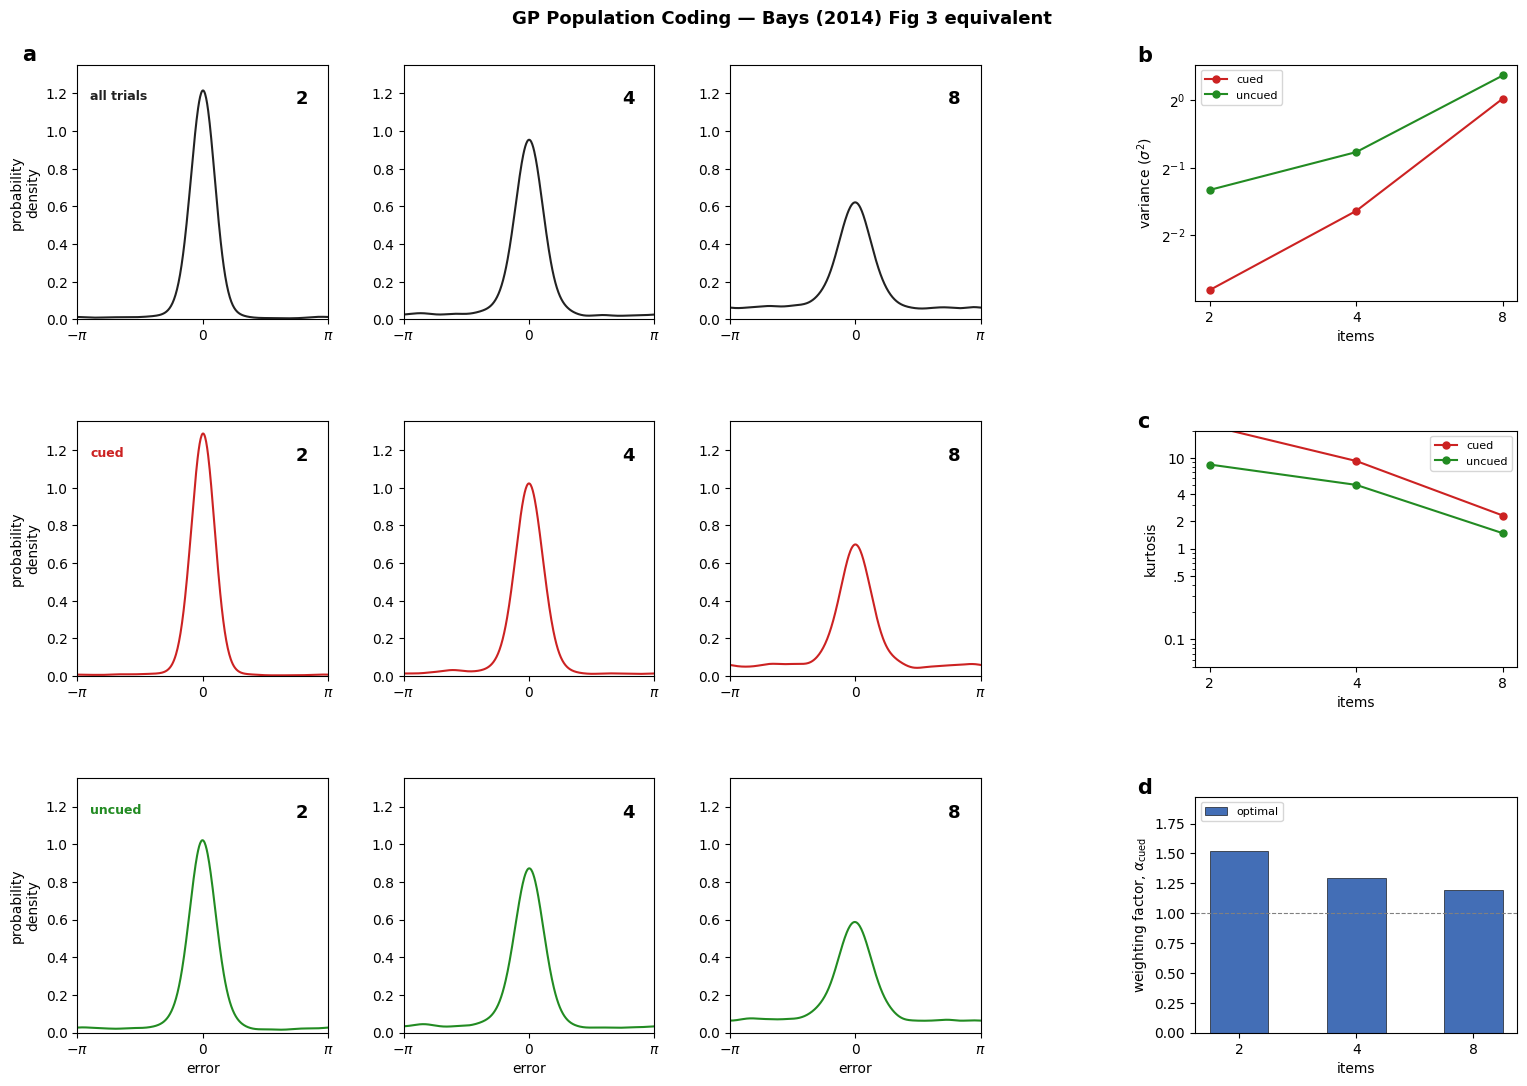

In [9]:
RED, GREEN, BLACK, BLUE = '#CC2222', '#228B22', '#222222', '#2255AA'
theta_smooth = np.linspace(-np.pi, np.pi, 500)

# Compute global y-max across all 9 error distributions
y_max = 0
for N in SET_SIZES:
    for err_key in ['err_all', 'err_cued', 'err_uncued']:
        density = vonmises_kde(summary[N][err_key], theta_smooth, kappa=KAPPA_KDE)
        y_max = max(y_max, np.max(density))
y_max *= 1.05  # 5% headroom

fig = plt.figure(figsize=(16, 11))
outer = gridspec.GridSpec(1, 2, width_ratios=[2.8, 1], wspace=0.35,
                          left=0.06, right=0.96, bottom=0.05, top=0.93)
gs_a = gridspec.GridSpecFromSubplotSpec(3, len(SET_SIZES),
    subplot_spec=outer[0], hspace=0.4, wspace=0.3)
gs_bcd = gridspec.GridSpecFromSubplotSpec(3, 1,
    subplot_spec=outer[1], hspace=0.55)
ns = np.array(SET_SIZES, dtype=float)

# === Panel a: error distributions (3 rows × 3 cols) ===
row_configs = [
    ('err_all', BLACK, 'all trials'),
    ('err_cued', RED, 'cued'),
    ('err_uncued', GREEN, 'uncued'),
]

for row, (err_key, color, label) in enumerate(row_configs):
    for col, N in enumerate(SET_SIZES):
        ax = fig.add_subplot(gs_a[row, col])
        err = summary[N][err_key]
        density = vonmises_kde(err, theta_smooth, kappa=KAPPA_KDE)
        ax.plot(theta_smooth, density, color=color, lw=1.5)
        ax.set_xlim(-np.pi, np.pi); ax.set_ylim(0, y_max)
        ax.set_xticks([-np.pi, 0, np.pi])
        ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
        if row == 2: ax.set_xlabel('error')
        ax.text(0.92, 0.90, f'{N}', transform=ax.transAxes,
                fontsize=13, fontweight='bold', va='top', ha='right')
        if col == 0:
            ax.set_ylabel('probability\ndensity')
            ax.text(0.05, 0.90, label, transform=ax.transAxes,
                    fontsize=9, fontweight='bold', va='top', color=color)

fig.axes[0].text(-0.22, 1.08, r'$\mathbf{a}$', transform=fig.axes[0].transAxes,
                  fontsize=15, fontweight='bold', va='top')

# === Panel b: variance (cued vs uncued) ===
ax_b = fig.add_subplot(gs_bcd[0])
vc = [summary[N]['vc'] for N in SET_SIZES]
vu = [summary[N]['vu'] for N in SET_SIZES]
ax_b.plot(ns, vc, 'o-', color=RED, lw=1.5, ms=5, label='cued')
ax_b.plot(ns, vu, 'o-', color=GREEN, lw=1.5, ms=5, label='uncued')
ax_b.set_xscale('log', base=2); ax_b.set_yscale('log', base=2)
ax_b.set_xticks(SET_SIZES); ax_b.set_xticklabels([str(n) for n in SET_SIZES])
ax_b.set_xlabel('items'); ax_b.set_ylabel(r'variance ($\sigma^2$)')
ax_b.legend(fontsize=8, loc='upper left')
ax_b.text(-0.18, 1.08, r'$\mathbf{b}$', transform=ax_b.transAxes,
          fontsize=15, fontweight='bold', va='top')

# === Panel c: kurtosis (cued vs uncued) ===
ax_c = fig.add_subplot(gs_bcd[1])
kc = [summary[N]['kc'] for N in SET_SIZES]
ku = [summary[N]['ku'] for N in SET_SIZES]
ax_c.plot(ns, kc, 'o-', color=RED, lw=1.5, ms=5, label='cued')
ax_c.plot(ns, ku, 'o-', color=GREEN, lw=1.5, ms=5, label='uncued')
ax_c.set_xscale('log', base=2)
ax_c.set_yscale('log')
ax_c.set_ylim(0.05, 20)
ax_c.set_yticks([0.1, 0.5, 1, 2, 4, 10])
ax_c.set_yticklabels(['0.1', '.5', '1', '2', '4', '10'])
ax_c.set_xticks(SET_SIZES); ax_c.set_xticklabels([str(n) for n in SET_SIZES])
ax_c.set_xlabel('items'); ax_c.set_ylabel('kurtosis')
ax_c.legend(fontsize=8, loc='upper right')
ax_c.text(-0.18, 1.08, r'$\mathbf{c}$', transform=ax_c.transAxes,
          fontsize=15, fontweight='bold', va='top')

# === Panel d: optimal weighting factor ===
ax_d = fig.add_subplot(gs_bcd[2])
bar_x = np.arange(len(SET_SIZES))
opt_alphas = [optimal_alphas[N] for N in SET_SIZES]
ax_d.bar(bar_x, opt_alphas, 0.5,
         color=BLUE, alpha=0.85, edgecolor='k', lw=0.5, label='optimal')
ax_d.axhline(1, color='gray', ls='--', lw=0.8)
ax_d.set_xticks(bar_x); ax_d.set_xticklabels([str(n) for n in SET_SIZES])
ax_d.set_xlabel('items')
ax_d.set_ylabel(r'weighting factor, $\alpha_{\mathrm{cued}}$')
ax_d.set_ylim(0, max(opt_alphas) * 1.3 if max(opt_alphas) > 1 else 2.0)
ax_d.legend(fontsize=8, loc='upper left')
ax_d.text(-0.18, 1.08, r'$\mathbf{d}$', transform=ax_d.transAxes,
          fontsize=15, fontweight='bold', va='top')

fig.suptitle('GP Population Coding \u2014 Bays (2014) Fig 3 equivalent',
             fontsize=13, fontweight='bold')
plt.savefig('bays_fig3_corrected.png', dpi=150, bbox_inches='tight')
plt.show()